# Import Library

In [10]:
# Basic
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

# Preprocessing & Evaluasi
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    KFold
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Bayesian Search (skopt)
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


# Load Dataset

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)
print("Shape y_train :", y_train.shape)
print("Shape y_test  :", y_test.shape)
print("\nFitur yang digunakan:")
print(X_train.columns.tolist())

Shape X_train : (13572, 9)
Shape X_test  : (3709, 9)
Shape y_train : (13572,)
Shape y_test  : (3709,)

Fitur yang digunakan:
['tahun', 'bulan', 'kuartal', 'wilayah_enc', 'komoditas_enc', 'harga_lag1', 'harga_lag2', 'harga_lag3', 'harga_rolling3']


#  Preview Data

In [3]:
print("=== X_train (5 baris pertama) ===")
display(X_train.head())

print("\n=== y_train statistik ===")
display(y_train.describe())

=== X_train (5 baris pertama) ===


,tahun,bulan,kuartal,wilayah_enc,komoditas_enc,harga_lag1,harga_lag2,harga_lag3,harga_rolling3
0,-1.0,-0.4,-1.0,-1.0,-1.0,0.748019,0.413136,0.451064,0.524350
1,-1.0,-0.2,-1.0,-1.0,-1.0,0.748019,0.756356,0.419149,0.626986
2,-1.0,0.0,0.0,-1.0,-1.0,0.824089,0.756356,0.763830,0.765230
3,-1.0,0.2,0.0,-1.0,-1.0,0.733228,0.832627,0.763830,0.760342
4,-1.0,0.4,0.0,-1.0,-1.0,0.409931,0.741525,0.840426,0.648630



=== y_train statistik ===


count     13572.000000
mean      33791.364574
std       33677.157449
min        7500.000000
25%       13500.000000
50%       19400.000000
75%       37200.000000
max      176650.000000
Name: harga, dtype: float64

# Mendefinisikan Model

In [4]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ),
}

print("✅ Model yang akan dilatih:")
for name in models:
    print(f"   - {name}")

✅ Model yang akan dilatih:
   - LinearRegression
   - Ridge
   - RandomForest
   - XGBoost
   - LightGBM


# Fungsi Evaluasi

In [5]:
def evaluate_model(y_true, y_pred):
    """Menghitung metrik evaluasi regresi."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE(%)': mape}

print("✅ Fungsi evaluate_model siap digunakan!")

✅ Fungsi evaluate_model siap digunakan!


# Training & Evaluasi Semua Model

In [8]:
results     = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results[name]     = evaluate_model(y_test, y_pred)
    print(f"✅ {name} selesai dilatih")

df_results = pd.DataFrame(results).T.sort_values('RMSE')
df_results = df_results.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
display(df_results)

✅ LinearRegression selesai dilatih
✅ Ridge selesai dilatih
✅ RandomForest selesai dilatih
✅ XGBoost selesai dilatih
✅ LightGBM selesai dilatih


,MAE,RMSE,R2,MAPE(%)
LightGBM,3048.0,6952.0,0.9610,6.69
RandomForest,3040.0,7001.0,0.9605,6.63
XGBoost,3160.0,7162.0,0.9586,7.05
LinearRegression,3017.0,7249.0,0.9576,6.70
Ridge,3018.0,7250.0,0.9576,6.70


# Pilih Model Terbaik

In [7]:
best_model_name = df_results.index[0]  # RMSE terkecil
best_pred       = predictions[best_model_name]
best_model      = models[best_model_name]

print(f"🏆 Model Terbaik : {best_model_name}")
print(f"   MAE    : {results[best_model_name]['MAE']:,.0f}")
print(f"   RMSE   : {results[best_model_name]['RMSE']:,.0f}")
print(f"   R²     : {results[best_model_name]['R2']:.4f}")
print(f"   MAPE   : {results[best_model_name]['MAPE(%)']:.2f}%")

🏆 Model Terbaik : LightGBM
   MAE    : 3,048
   RMSE   : 6,952
   R²     : 0.9610
   MAPE   : 6.69%


# Grid Search

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1],
    'max_depth'     : [5, 7, -1],
    'num_leaves'    : [31, 50],
}

grid_search = GridSearchCV(
    estimator  = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_grid = param_grid,
    scoring    = 'neg_root_mean_squared_error',
    cv         = cv,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train)

grid_pred    = grid_search.best_estimator_.predict(X_test)
grid_metrics = evaluate_model(y_test, grid_pred)

print("\n✅ Grid Search selesai!")
print(f"   Best Params : {grid_search.best_params_}")
print(f"   CV RMSE     : {-grid_search.best_score_:,.0f}")
print(f"   Test RMSE   : {grid_metrics['RMSE']:,.0f} | R²: {grid_metrics['R2']:.4f} | MAPE: {grid_metrics['MAPE(%)']:.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Grid Search selesai!
   Best Params : {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 50}
   CV RMSE     : 4,275
   Test RMSE   : 7,379 | R²: 0.9561 | MAPE: 7.21%


# Randomized Search

In [13]:
param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'learning_rate'     : [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth'         : [3, 5, 7, 9, -1],
    'num_leaves'        : [20, 31, 50, 70, 100],
    'min_child_samples' : [10, 20, 30, 50],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'         : [0, 0.01, 0.1, 0.5],
    'reg_lambda'        : [0, 0.01, 0.1, 0.5, 1.0],
}

random_search = RandomizedSearchCV(
    estimator           = lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_distributions = param_dist,
    n_iter              = 50,
    scoring             = 'neg_root_mean_squared_error',
    cv                  = cv,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1
)
random_search.fit(X_train, y_train)

random_pred    = random_search.best_estimator_.predict(X_test)
random_metrics = evaluate_model(y_test, random_pred)

print("\n✅ Randomized Search selesai!")
print(f"   Best Params : {random_search.best_params_}")
print(f"   CV RMSE     : {-random_search.best_score_:,.0f}")
print(f"   Test RMSE   : {random_metrics['RMSE']:,.0f} | R²: {random_metrics['R2']:.4f} | MAPE: {random_metrics['MAPE(%)']:.2f}%")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Randomized Search selesai!
   Best Params : {'subsample': 0.7, 'reg_lambda': 0.01, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 200, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
   CV RMSE     : 4,331
   Test RMSE   : 7,076 | R²: 0.9596 | MAPE: 6.86%


# Bayesian Search

In [14]:
bayes_space = {
    'n_estimators'      : Integer(100, 500),
    'learning_rate'     : Real(0.01, 0.2, prior='log-uniform'),
    'max_depth'         : Integer(3, 10),
    'num_leaves'        : Integer(20, 100),
    'min_child_samples' : Integer(10, 50),
    'subsample'         : Real(0.6, 1.0),
    'colsample_bytree'  : Real(0.6, 1.0),
    'reg_alpha'         : Real(0.0, 0.5),
    'reg_lambda'        : Real(0.0, 1.0),
}

bayes_search = BayesSearchCV(
    estimator  = lgb.LGBMRegressor(random_state=42, verbose=-1),
    search_spaces = bayes_space,
    n_iter     = 50,
    scoring    = 'neg_root_mean_squared_error',
    cv         = cv,
    random_state = 42,
    n_jobs     = -1,
    verbose    = 1
)
bayes_search.fit(X_train, y_train)

bayes_pred    = bayes_search.best_estimator_.predict(X_test)
bayes_metrics = evaluate_model(y_test, bayes_pred)

print("\n✅ Bayesian Search selesai!")
print(f"   Best Params : {dict(bayes_search.best_params_)}")
print(f"   CV RMSE     : {-bayes_search.best_score_:,.0f}")
print(f"   Test RMSE   : {bayes_metrics['RMSE']:,.0f} | R²: {bayes_metrics['R2']:.4f} | MAPE: {bayes_metrics['MAPE(%)']:.2f}%")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

# Optuna

In [15]:
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 50),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state'      : 42,
        'verbose'           : -1,
    }

    model  = lgb.LGBMRegressor(**params)
    scores = []
    for train_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        pred  = model.predict(X_val)
        rmse  = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(rmse)
    return np.mean(scores)

study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Train ulang dengan best params
optuna_model = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
optuna_model.fit(X_train, y_train)
optuna_pred    = optuna_model.predict(X_test)
optuna_metrics = evaluate_model(y_test, optuna_pred)

print("\n✅ Optuna selesai!")
print(f"   Best Params : {study.best_params}")
print(f"   CV RMSE     : {study.best_value:,.0f}")
print(f"   Test RMSE   : {optuna_metrics['RMSE']:,.0f} | R²: {optuna_metrics['R2']:.4f} | MAPE: {optuna_metrics['MAPE(%)']:.2f}%")

  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna selesai!
   Best Params : {'n_estimators': 387, 'learning_rate': 0.16218616800918867, 'max_depth': 9, 'num_leaves': 44, 'min_child_samples': 10, 'subsample': 0.7818364826244784, 'colsample_bytree': 0.7242608339258686, 'reg_alpha': 0.18722717958977514, 'reg_lambda': 0.5522293902485167}
   CV RMSE     : 4,140
   Test RMSE   : 7,450 | R²: 0.9552 | MAPE: 7.45%


# Rekap Semua Hasil Tuning

In [16]:
tuning_results = {
    'LightGBM (Default)'  : results['LightGBM'],
    'Grid Search'         : grid_metrics,
    'Randomized Search'   : random_metrics,
    'Bayesian Search'     : bayes_metrics,
    'Optuna'              : optuna_metrics,
}

df_tuning = pd.DataFrame(tuning_results).T
df_tuning = df_tuning.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
df_tuning = df_tuning.sort_values('RMSE')

print("📊 Rekap Hasil Semua Metode Tuning:")
display(df_tuning)

best_tuning_name = df_tuning.index[0]
print(f"\n🏆 Metode terbaik: {best_tuning_name}")

📊 Rekap Hasil Semua Metode Tuning:


,MAE,RMSE,R2,MAPE(%)
LightGBM (Default),3048.0,6952.0,0.9610,6.69
Randomized Search,3091.0,7076.0,0.9596,6.86
Grid Search,3256.0,7379.0,0.9561,7.21
Optuna,3321.0,7450.0,0.9552,7.45
Bayesian Search,3426.0,7814.0,0.9508,7.77



🏆 Metode terbaik: LightGBM (Default)


# Set Final Model

In [17]:
final_model = models['LightGBM']
final_pred  = predictions['LightGBM']

print("✅ Final model: LightGBM Default")
print(f"   MAE   : {results['LightGBM']['MAE']:,.0f}")
print(f"   RMSE  : {results['LightGBM']['RMSE']:,.0f}")
print(f"   R²    : {results['LightGBM']['R2']:.4f}")
print(f"   MAPE  : {results['LightGBM']['MAPE(%)']:.2f}%")

✅ Final model: LightGBM Default
   MAE   : 3,048
   RMSE  : 6,952
   R²    : 0.9610
   MAPE  : 6.69%


# Plot Perbandingan Semua Metode Tuning

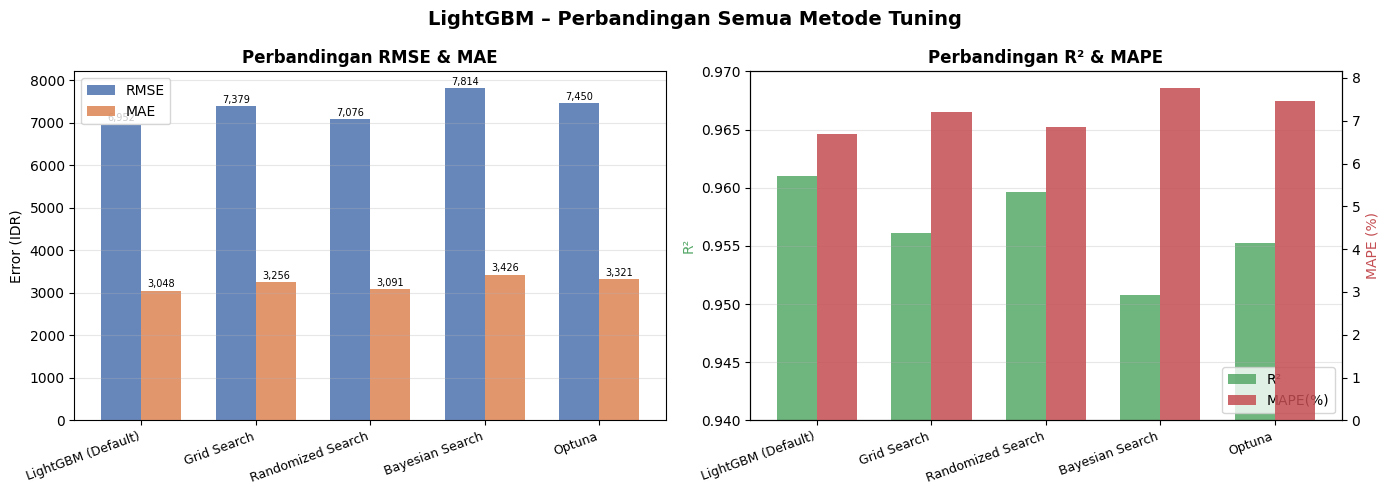

In [18]:
tuning_results = {
    'LightGBM (Default)' : results['LightGBM'],
    'Grid Search'        : grid_metrics,
    'Randomized Search'  : random_metrics,
    'Bayesian Search'    : bayes_metrics,
    'Optuna'             : optuna_metrics,
}

names     = list(tuning_results.keys())
rmse_vals = [tuning_results[m]['RMSE'] for m in names]
mae_vals  = [tuning_results[m]['MAE']  for m in names]
r2_vals   = [tuning_results[m]['R2']   for m in names]
mape_vals = [tuning_results[m]['MAPE(%)'] for m in names]
x     = np.arange(len(names))
bar_w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- RMSE & MAE ---
b1 = axes[0].bar(x - bar_w/2, rmse_vals, bar_w, label='RMSE', color='#4C72B0', alpha=0.85)
b2 = axes[0].bar(x + bar_w/2, mae_vals,  bar_w, label='MAE',  color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Perbandingan RMSE & MAE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error (IDR)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7)

# --- R² & MAPE ---
ax2 = axes[1].twinx()
b3 = axes[1].bar(x - bar_w/2, r2_vals,   bar_w, label='R²',     color='#55A868', alpha=0.85)
b4 = ax2.bar    (x + bar_w/2, mape_vals, bar_w, label='MAPE(%)', color='#C44E52', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Perbandingan R² & MAPE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²', color='#55A868')
ax2.set_ylabel('MAPE (%)', color='#C44E52')
axes[1].set_ylim(0.94, 0.97)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('LightGBM – Perbandingan Semua Metode Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel Rekap Semua Metode

In [19]:
df_tuning = pd.DataFrame(tuning_results).T
df_tuning = df_tuning.round({'MAE': 0, 'RMSE': 0, 'R2': 4, 'MAPE(%)': 2})
df_tuning = df_tuning.sort_values('RMSE')

# Highlight baris terbaik
def highlight_best(s):
    is_best = s == s.min() if s.name in ['MAE', 'RMSE', 'MAPE(%)'] else s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_best]

print("📊 Rekap Hasil Semua Metode Tuning:")
df_tuning.style.apply(highlight_best)

📊 Rekap Hasil Semua Metode Tuning:


,MAE,RMSE,R2,MAPE(%)
LightGBM (Default),3048.000000,6952.000000,0.961000,6.690000
Randomized Search,3091.000000,7076.000000,0.959600,6.860000
Grid Search,3256.000000,7379.000000,0.956100,7.210000
Optuna,3321.000000,7450.000000,0.955200,7.450000
Bayesian Search,3426.000000,7814.000000,0.950800,7.770000


# Plot Actual vs Predicted

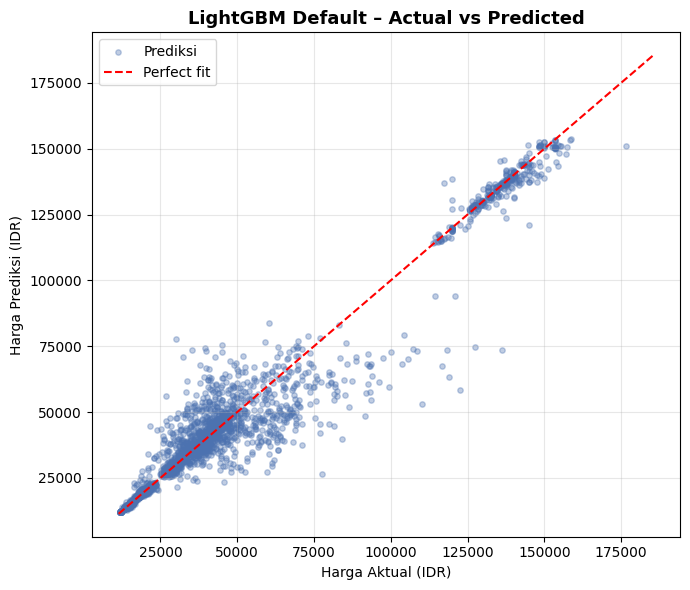

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, final_pred, alpha=0.35, s=15, color='#4C72B0', label='Prediksi')
lims = [min(y_test.min(), final_pred.min()) * 0.95,
        max(y_test.max(), final_pred.max()) * 1.05]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Harga Aktual (IDR)')
ax.set_ylabel('Harga Prediksi (IDR)')
ax.set_title('LightGBM Default – Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  Plot Distribusi Residual

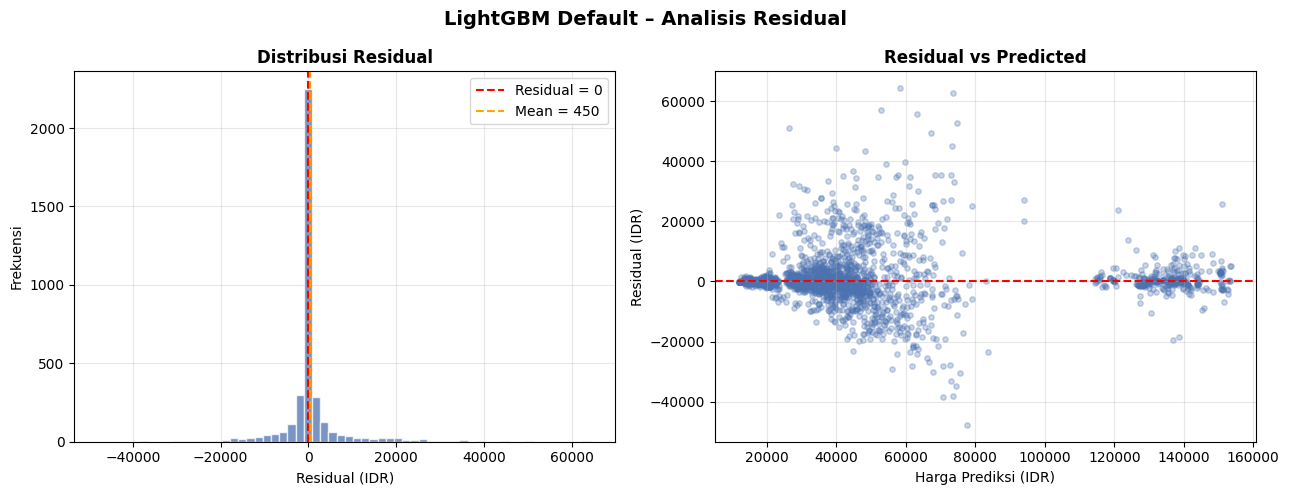

In [21]:
residuals = y_test.values - final_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Histogram residual ---
axes[0].hist(residuals, bins=60, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', lw=1.5, linestyle='--', label='Residual = 0')
axes[0].axvline(np.mean(residuals), color='orange', lw=1.5, linestyle='--',
                label=f'Mean = {np.mean(residuals):,.0f}')
axes[0].set_xlabel('Residual (IDR)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Residual', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Residual vs Predicted (scatter) ---
axes[1].scatter(final_pred, residuals, alpha=0.3, s=15, color='#4C72B0')
axes[1].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Harga Prediksi (IDR)')
axes[1].set_ylabel('Residual (IDR)')
axes[1].set_title('Residual vs Predicted', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('LightGBM Default – Analisis Residual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot Feature Importance

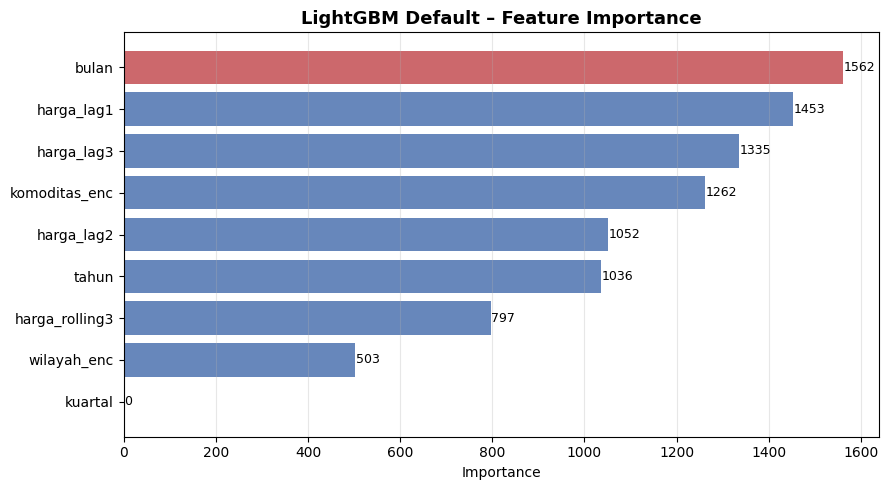

In [22]:
feature_imp = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values()

colors_fi = ['#4C72B0' if v < feature_imp.max() else '#C44E52' for v in feature_imp]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feature_imp.index, feature_imp.values, color=colors_fi, alpha=0.85)
ax.set_title('LightGBM Default – Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
for bar, val in zip(bars, feature_imp.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Error Distribution per Kuartil Harga

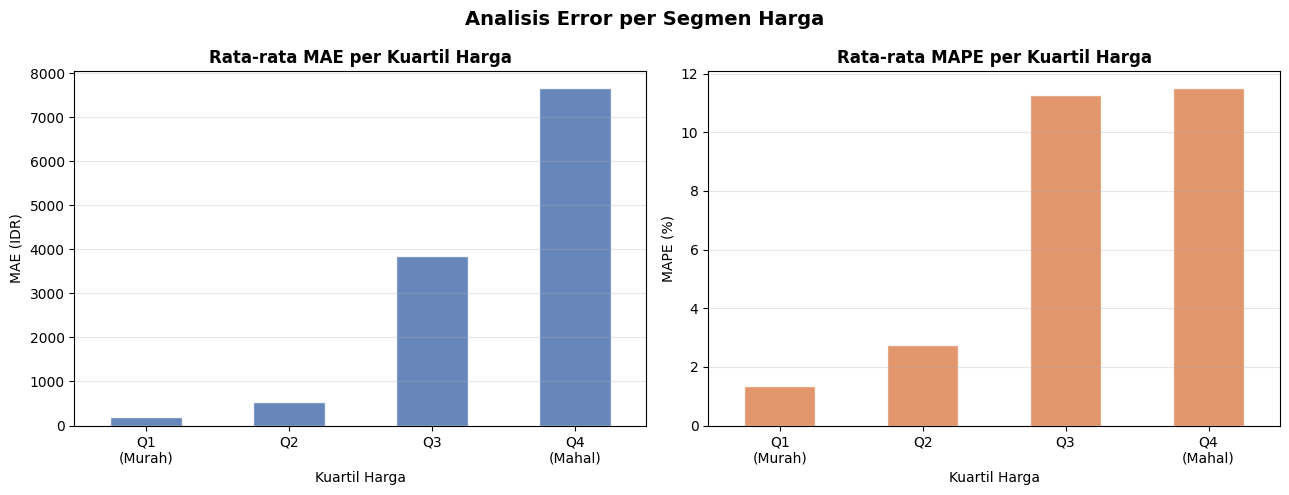

In [23]:
df_eval = pd.DataFrame({
    'harga_aktual'  : y_test.values,
    'harga_prediksi': final_pred,
    'error_abs'     : np.abs(y_test.values - final_pred),
    'mape_per_row'  : np.abs((y_test.values - final_pred) / y_test.values) * 100
})

df_eval['kuartil'] = pd.qcut(df_eval['harga_aktual'], q=4,
                              labels=['Q1\n(Murah)', 'Q2', 'Q3', 'Q4\n(Mahal)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- MAE per kuartil ---
df_eval.groupby('kuartil')['error_abs'].mean().plot(
    kind='bar', ax=axes[0], color='#4C72B0', alpha=0.85, edgecolor='white')
axes[0].set_title('Rata-rata MAE per Kuartil Harga', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kuartil Harga')
axes[0].set_ylabel('MAE (IDR)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# --- MAPE per kuartil ---
df_eval.groupby('kuartil')['mape_per_row'].mean().plot(
    kind='bar', ax=axes[1], color='#DD8452', alpha=0.85, edgecolor='white')
axes[1].set_title('Rata-rata MAPE per Kuartil Harga', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kuartil Harga')
axes[1].set_ylabel('MAPE (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Analisis Error per Segmen Harga', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Learning Curve

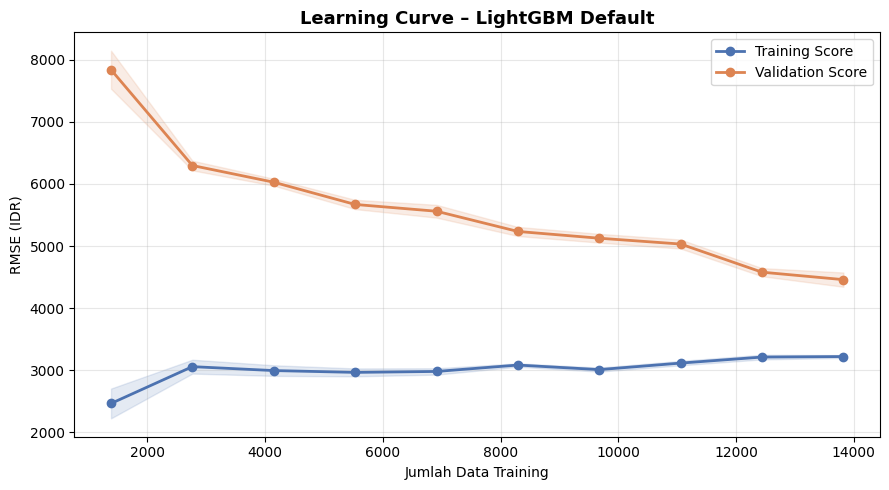


📊 Training RMSE akhir  : 3,222
📊 Validation RMSE akhir: 4,459
📊 Gap                  : 1,238
✅  Model fit dengan baik (tidak overfit / underfit)


In [24]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    estimator  = final_model,
    X          = pd.concat([X_train, X_test]),
    y          = pd.concat([y_train, y_test]),
    train_sizes= np.linspace(0.1, 1.0, 10),
    scoring    = 'neg_root_mean_squared_error',
    cv         = KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs     = -1,
    verbose    = 0
)

# Konversi ke positif
train_scores_mean = -train_scores.mean(axis=1)
train_scores_std  = train_scores.std(axis=1)
val_scores_mean   = -val_scores.mean(axis=1)
val_scores_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

# Plot garis
ax.plot(train_sizes, train_scores_mean, 'o-', color='#4C72B0',
        lw=2, label='Training Score')
ax.plot(train_sizes, val_scores_mean,   'o-', color='#DD8452',
        lw=2, label='Validation Score')

# Shading area std
ax.fill_between(train_sizes,
                train_scores_mean - train_scores_std,
                train_scores_mean + train_scores_std,
                alpha=0.15, color='#4C72B0')
ax.fill_between(train_sizes,
                val_scores_mean - val_scores_std,
                val_scores_mean + val_scores_std,
                alpha=0.15, color='#DD8452')

ax.set_title('Learning Curve – LightGBM Default', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Data Training')
ax.set_ylabel('RMSE (IDR)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Kesimpulan otomatis
gap = abs(train_scores_mean[-1] - val_scores_mean[-1])
print(f"\n📊 Training RMSE akhir  : {train_scores_mean[-1]:,.0f}")
print(f"📊 Validation RMSE akhir: {val_scores_mean[-1]:,.0f}")
print(f"📊 Gap                  : {gap:,.0f}")

if gap > 3000:
    print("⚠️  Gap cukup besar → indikasi overfitting")
elif train_scores_mean[-1] > 5000:
    print("⚠️  Training RMSE masih tinggi → indikasi underfitting")
else:
    print("✅  Model fit dengan baik (tidak overfit / underfit)")